In [1]:
#Aks primality test

import math

def expand_poly_mod(a, n, mod):
    """Computes (x + a)^n mod (x^r - 1, n)"""
    result = [1]

    bin_n = bin(n)[2:]

    poly = [a, 1]

    for bit in bin_n:
        result = multiply_poly(result, result, mod)

        if bit == '1':
            result = multiply_poly(result, poly, mod)

    return result

def multiply_poly(poly1, poly2, mod):
    """Multiply two polynomials modulo mod"""
    result = [0] * (len(poly1) + len(poly2) - 1)

    for i in range(len(poly1)):
        for j in range(len(poly2)):
            result[i + j] = (result[i + j] + poly1[i] * poly2[j]) % mod

    return result

def reduce_poly_mod_xr_minus_1(poly, r, mod):
    """Reduce polynomial modulo (x^r - 1, n)"""
    result = [0] * r

    for i in range(len(poly)):
        result[i % r] = (result[i % r] + poly[i]) % mod

    return result

def aks_primality_test(n):
    """
    AKS primality test implementation
    """
    max_log = int(math.log2(n)) + 1
    for b in range(2, max_log + 1):
        a = int(n ** (1 / b))
        if a ** b == n:
            return False

    log_squared = (math.log2(n)) ** 2
    r = 2

    while r <= max(3, log_squared):
        if math.gcd(n, r) > 1:
            if n > r:
                return False
            return n == r

        ord_r = 1
        power = n % r

        while power != 1 and ord_r <= log_squared:
            power = (power * n) % r
            ord_r += 1

        if ord_r > log_squared:
            break

        r += 1

    for a in range(2, r + 1):
        if math.gcd(a, n) > 1:
            return a == n

    if n <= r:
        return True

    limit = int(math.sqrt(r - 1) * math.log(n))

    for a in range(1, limit + 1):
        poly = [a, 1]
        left_poly = expand_poly_mod(a, n, n)
        left_poly = reduce_poly_mod_xr_minus_1(left_poly, r, n)

        right_poly = [0] * r
        right_poly[0] = a
        right_poly[n % r] = (right_poly[n % r] + 1) % n

        if left_poly != right_poly:
            return False

    return True

if __name__ == "__main__":
    test_numbers = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37]

    print("Testing AKS primality test:")
    for n in test_numbers:
        result = aks_primality_test(n)
        print(f"{n} is prime: {result}")

    print("\nTesting some composites:")
    composites = [4, 6, 8, 9, 10, 12, 14, 15, 16, 18, 20]
    for n in composites:
        result = aks_primality_test(n)
        print(f"{n} is prime: {result}")

Testing AKS primality test:
2 is prime: True
3 is prime: True
5 is prime: True
7 is prime: True
11 is prime: True
13 is prime: True
17 is prime: True
19 is prime: True
23 is prime: True
29 is prime: True
31 is prime: True
37 is prime: True

Testing some composites:
4 is prime: False
6 is prime: False
8 is prime: False
9 is prime: False
10 is prime: False
12 is prime: False
14 is prime: False
15 is prime: False
16 is prime: False
18 is prime: False
20 is prime: False


In [2]:
#Miller rabin test

import random

def power_mod(base, exponent, modulus):
    """Compute (base^exponent) % modulus efficiently using square-and-multiply"""
    result = 1
    base = base % modulus
    while exponent > 0:
        if exponent % 2 == 1:
            result = (result * base) % modulus
        exponent = exponent >> 1
        base = (base * base) % modulus
    return result

def miller_rabin_test(n, k=40):
    """
    Miller-Rabin primality test
    n: number to test for primality
    k: number of rounds/witnesses to test
    Returns: True if probably prime, False if definitely composite
    """
    if n == 2 or n == 3:
        return True
    if n <= 1 or n % 2 == 0:
        return False

    r, d = 0, n - 1
    while d % 2 == 0:
        r += 1
        d //= 2

    for _ in range(k):
        a = random.randint(2, n - 2)
        x = power_mod(a, d, n)

        if x == 1 or x == n - 1:
            continue

        for _ in range(r - 1):
            x = power_mod(x, 2, n)
            if x == n - 1:
                break
        else:
            return False

    return True

def miller_rabin_wrapper(n, k=40):
    """
    Wrapper function to handle large integers
    n: number to test (can be integer or string representation)
    k: number of witnesses to test
    """
    if isinstance(n, str):
        n = int(n)
    return miller_rabin_test(n, k)

def generate_large_prime(bits, k=40):
    """
    Generate a random prime number with the specified bit length
    bits: number of bits (e.g., 1024 for a 1024-bit prime)
    k: number of witnesses for Miller-Rabin test
    """
    while True:
        p = random.getrandbits(bits) | (1 << (bits - 1)) | 1

        if miller_rabin_wrapper(p, k):
            return p

if __name__ == "__main__":
    test_numbers = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37]

    print("Testing Miller-Rabin primality test:")
    for n in test_numbers:
        result = miller_rabin_wrapper(n)
        print(f"{n} is prime: {result}")

    print("\nTesting some composites:")
    composites = [4, 6, 8, 9, 10, 12, 14, 15, 16, 18, 20]
    for n in composites:
        result = miller_rabin_wrapper(n)
        print(f"{n} is prime: {result}")

    print("\nGenerating a 512-bit prime:")
    prime = generate_large_prime(512)
    print(f"Generated prime: {prime}")
    print(f"Number of digits: {len(str(prime))}")
    print(f"Verified prime by Rabin's Algo: {miller_rabin_wrapper(prime)}")

Testing Miller-Rabin primality test:
2 is prime: True
3 is prime: True
5 is prime: True
7 is prime: True
11 is prime: True
13 is prime: True
17 is prime: True
19 is prime: True
23 is prime: True
29 is prime: True
31 is prime: True
37 is prime: True

Testing some composites:
4 is prime: False
6 is prime: False
8 is prime: False
9 is prime: False
10 is prime: False
12 is prime: False
14 is prime: False
15 is prime: False
16 is prime: False
18 is prime: False
20 is prime: False

Generating a 512-bit prime:
Generated prime: 13343580552110885614956024850067430838341981126623821693446828009441386079670629114201794854703744773246384469065489614021265734363808255806817231697052997
Number of digits: 155
Verified prime by Rabin's Algo: True


Running primality testing experiments...

Experiment 1: Execution Time Comparison
Bit Size | Execution Time (s)
------------------------------
Testing for 64 bits... 0.000000s
Testing for 128 bits... 0.000000s
Testing for 192 bits... 0.000000s
Testing for 256 bits... 0.000000s
Testing for 320 bits... 0.000912s
Testing for 384 bits... 0.000000s
Testing for 448 bits... 0.001071s
Testing for 512 bits... 0.001000s
Testing for 576 bits... 0.000000s
Testing for 640 bits... 0.002648s
Testing for 704 bits... 0.001947s
Testing for 768 bits... 0.002031s
Testing for 832 bits... 0.002995s
Testing for 896 bits... 0.002942s
Testing for 960 bits... 0.004009s
Testing for 1024 bits... 0.005998s

Results saved to execution_time_comparison.png

Experiment 3: Error Probability Analysis

Number of Witnesses | Agreement Rate
-----------------------------------
Testing with 1 witnesses... 1.0000
Testing with 2 witnesses... 1.0000
Testing with 3 witnesses... 1.0000
Testing with 5 witnesses... 1.0000
Testing w

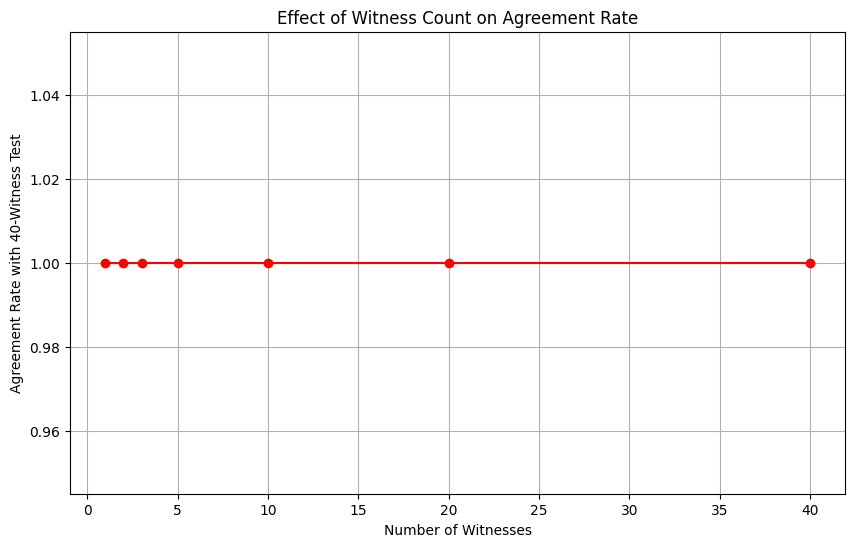


Results saved to error_probability.png

Experiment 5: Theoretical vs Actual Performance

Bit Size | Execution Time (s)
------------------------------
Testing 64-bit number... 0.000197s
Testing 128-bit number... 0.000000s
Testing 256-bit number... 0.000200s
Testing 384-bit number... 0.000400s
Testing 512-bit number... 0.001002s
Testing 768-bit number... 0.002599s
Testing 1024-bit number... 0.005245s
Testing 1536-bit number... 0.016200s
Testing 2048-bit number... 0.039889s

Results saved to theoretical_vs_actual.png

All experiments completed!


In [3]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np

def experiment_execution_time(max_bits=1024, step=32):
    """
    Compare execution time of Miller-Rabin test for different bit sizes
    """
    bits_sizes = list(range(step, max_bits + 1, step))
    times_miller_rabin = []

    print("Bit Size | Execution Time (s)")
    print("-" * 30)

    for bits in bits_sizes:
        print(f"Testing for {bits} bits...", end="")
        n = random.getrandbits(bits) | (1 << (bits - 1)) | 1

        start_time = time.time()
        miller_rabin_wrapper(n, k=10)
        end_time = time.time()
        exec_time = end_time - start_time
        times_miller_rabin.append(exec_time)

        print(f" {exec_time:.6f}s")

    plt.figure(figsize=(10, 6))
    plt.plot(bits_sizes, times_miller_rabin, 'bo-', label='Miller-Rabin')

    coeffs = np.polyfit(bits_sizes, times_miller_rabin, 2)
    poly = np.poly1d(coeffs)
    x_trend = np.linspace(min(bits_sizes), max(bits_sizes), 100)
    plt.plot(x_trend, poly(x_trend), 'r--', label=f'Trend: {poly}')

    plt.xlabel('Number of Bits')
    plt.ylabel('Execution Time (seconds)')
    plt.title('Execution Time vs. Bit Size for Miller-Rabin Primality Test')
    plt.legend()
    plt.grid(True)
    plt.savefig('execution_time_comparison.png')
    plt.close()

    print(f"\nResults saved to execution_time_comparison.png")
    return bits_sizes, times_miller_rabin


def experiment_error_probability(num_tests=50, bit_size=256, witnesses_range=[1, 2, 3, 5, 10, 20, 40]):
    """
    Demonstrate how the number of witnesses affects the error probability
    Analyze consistency across multiple runs
    """
    results = {}

    print("\nNumber of Witnesses | Agreement Rate")
    print("-" * 35)

    for witnesses in witnesses_range:
        print(f"Testing with {witnesses} witnesses...", end="")
        agreements = 0

        for _ in range(num_tests):
            n = generate_large_prime(bit_size, k=40)

            test_result = miller_rabin_wrapper(n, k=witnesses)
            if test_result:
                agreements += 1

        agreement_rate = agreements / num_tests
        results[witnesses] = agreement_rate
        print(f" {agreement_rate:.4f}")

    plt.figure(figsize=(10, 6))
    plt.plot(list(results.keys()), list(results.values()), 'ro-')
    plt.xlabel('Number of Witnesses')
    plt.ylabel('Agreement Rate with 40-Witness Test')
    plt.title('Effect of Witness Count on Agreement Rate')
    plt.grid(True)
    plt.savefig('error_probability.png')
    plt.show()
    plt.close()

    print(f"\nResults saved to error_probability.png")
    return results

def experiment_theoretical_vs_actual():
    """
    Compare theoretical O(log^2 n) performance with actual performance
    """
    bit_sizes = [64, 128, 256, 384, 512, 768, 1024, 1536, 2048]
    times = []

    print("\nBit Size | Execution Time (s)")
    print("-" * 30)

    for bits in bit_sizes:
        print(f"Testing {bits}-bit number...", end="")
        n = random.getrandbits(bits) | (1 << (bits - 1)) | 1

        num_runs = 5
        total_time = 0

        for _ in range(num_runs):
            start_time = time.time()
            miller_rabin_wrapper(n, k=10)
            end_time = time.time()
            total_time += (end_time - start_time)

        avg_time = total_time / num_runs
        times.append(avg_time)
        print(f" {avg_time:.6f}s")

    plt.figure(figsize=(10, 6))
    plt.plot(bit_sizes, times, 'bo-', label='Actual Time')

    reference_idx = bit_sizes.index(256)
    k = times[reference_idx] / (256 ** 2)
    theoretical = [k * (b ** 2) for b in bit_sizes]

    plt.plot(bit_sizes, theoretical, 'r--', label='O(log^2 n) Theoretical')

    plt.xlabel('Number of Bits')
    plt.ylabel('Execution Time (seconds)')
    plt.title('Miller-Rabin: Actual vs Theoretical O(log^2 n) Performance')
    plt.legend()
    plt.grid(True)
    plt.savefig('theoretical_vs_actual.png')
    plt.close()

    print(f"\nResults saved to theoretical_vs_actual.png")
    return bit_sizes, times, theoretical

if __name__ == "__main__":
    print("Running primality testing experiments...")

    run_execution_time = True
    
    run_error_probability = True
    
    run_theoretical = True

    results = {}

    if run_execution_time:
        print("\nExperiment 1: Execution Time Comparison")
        bits_sizes, times = experiment_execution_time(max_bits=1024, step=64)
        results['execution_time'] = {'bits': bits_sizes, 'times': times}


    if run_error_probability:
        print("\nExperiment 3: Error Probability Analysis")
        error_results = experiment_error_probability(num_tests=30)
        results['error_probability'] = error_results


    if run_theoretical:
        print("\nExperiment 5: Theoretical vs Actual Performance")
        bit_sizes, actual_times, theoretical_times = experiment_theoretical_vs_actual()
        results['theoretical'] = {
            'bit_sizes': bit_sizes,
            'actual': actual_times,
            'theoretical': theoretical_times
        }

    print("\nAll experiments completed!")

Bits | Time (s)
-------------------------
  32 | 0.000000
  64 | 0.000000
  96 | 0.000000
 128 | 0.000000
 160 | 0.001001
 192 | 0.000000
 224 | 0.000000
 256 | 0.000000
 288 | 0.000000
 320 | 0.000998
 352 | 0.000000
 384 | 0.001002
 416 | 0.000000
 448 | 0.000999
 480 | 0.001000
 512 | 0.000999
 544 | 0.001002
 576 | 0.001144
 608 | 0.002013
 640 | 0.001994
 672 | 0.002000
 704 | 0.003000
 736 | 0.002001
 768 | 0.002998
 800 | 0.004001
 832 | 0.002999
 864 | 0.004001
 896 | 0.004009
 928 | 0.004997
 960 | 0.004997
 992 | 0.004997
1024 | 0.007007
1056 | 0.005998
1088 | 0.006007
1120 | 0.007505
1152 | 0.007008
1184 | 0.008994
1216 | 0.009352
1248 | 0.008985
1280 | 0.009000
1312 | 0.010002
1344 | 0.011999
1376 | 0.013006
1408 | 0.011998
1440 | 0.014073
1472 | 0.015001
1504 | 0.017000
1536 | 0.015006
1568 | 0.017993
1600 | 0.020014
1632 | 0.019580
1664 | 0.019985
1696 | 0.023999
1728 | 0.025000
1760 | 0.022527
1792 | 0.025006
1824 | 0.024995
1856 | 0.025999
1888 | 0.028183
1920 | 0.03000

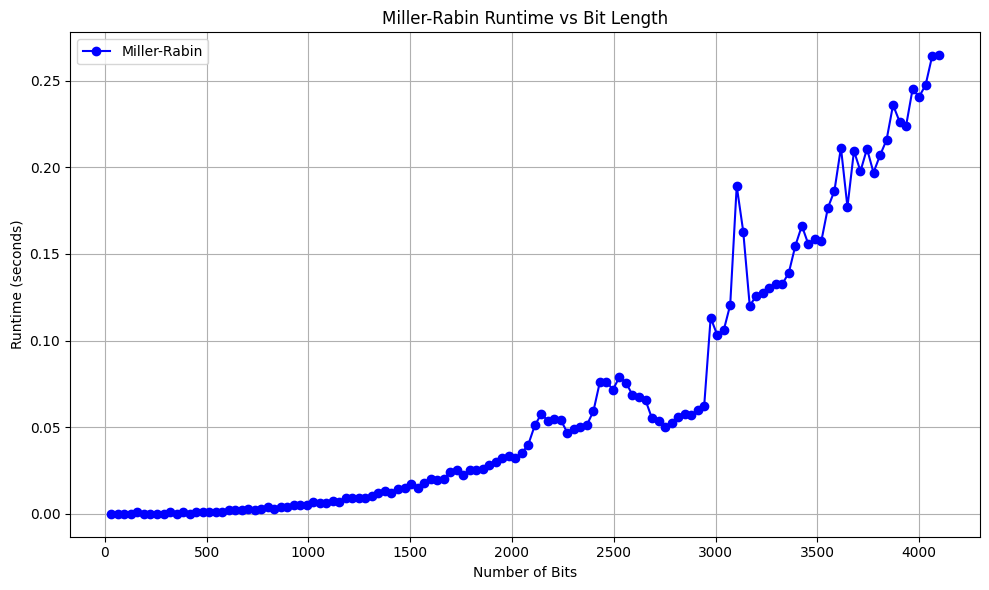

In [4]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np


def generate_random_odd_number(bits):
    """Generate a random odd number of given bit size"""
    return random.getrandbits(bits) | (1 << (bits - 1)) | 1


def experiment_mr_runtime(max_bits=4096, step=32, k=10):
    """
    Generate runtime vs bit-length plot for Miller-Rabin
    """

    bit_sizes = list(range(step, max_bits + 1, step))
    times = []

    print("Bits | Time (s)")
    print("-" * 25)

    for bits in bit_sizes:
        n = generate_random_odd_number(bits)

        start = time.time()
        miller_rabin_wrapper(n, k)
        end = time.time()

        t = end - start
        times.append(t)

        print(f"{bits:4d} | {t:.6f}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(bit_sizes, times, 'bo-', label='Miller-Rabin')

    # Optional trend line (like your notebook)
    coeffs = np.polyfit(bit_sizes, times, 2)
    poly = np.poly1d(coeffs)
    x_trend = np.linspace(min(bit_sizes), max(bit_sizes), 200)

    #plt.plot(x_trend, poly(x_trend), 'r--', label='Trend (quadratic fit)')

    plt.xlabel("Number of Bits")
    plt.ylabel("Runtime (seconds)")
    plt.title("Miller-Rabin Runtime vs Bit Length")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("mr_runtime_plot.png", dpi=300)
    plt.show()


# Run experiment
experiment_mr_runtime(max_bits=4096, step=32, k=20)

Bits | Avg Time (s)
------------------------------
  32 | 0.000000
  64 | 0.000200
  96 | 0.000000
 128 | 0.000201
 160 | 0.000000
 192 | 0.000199
 224 | 0.000200
 256 | 0.000202
 288 | 0.000215
 320 | 0.000401
 352 | 0.000583
 384 | 0.000400
 416 | 0.000600
 448 | 0.000802
 480 | 0.000798
 512 | 0.001000
 544 | 0.001400
 576 | 0.001403
 608 | 0.001400
 640 | 0.001905
 672 | 0.002000
 704 | 0.002199
 736 | 0.002200
 768 | 0.002617
 800 | 0.003002
 832 | 0.003182
 864 | 0.003424
 896 | 0.003892
 928 | 0.004200
 960 | 0.006399
 992 | 0.008104
1024 | 0.007197
1056 | 0.006983
1088 | 0.007942
1120 | 0.007320
1152 | 0.007979
1184 | 0.008488
1216 | 0.009202
1248 | 0.009921
1280 | 0.010202
1312 | 0.010728
1344 | 0.011540
1376 | 0.014724
1408 | 0.013805
1440 | 0.016003
1472 | 0.015600
1504 | 0.016018
1536 | 0.017104
1568 | 0.017906
1600 | 0.018311
1632 | 0.019653
1664 | 0.025505
1696 | 0.023303
1728 | 0.022183
1760 | 0.023405
1792 | 0.025102
1824 | 0.028304
1856 | 0.034411
1888 | 0.031460
1920 

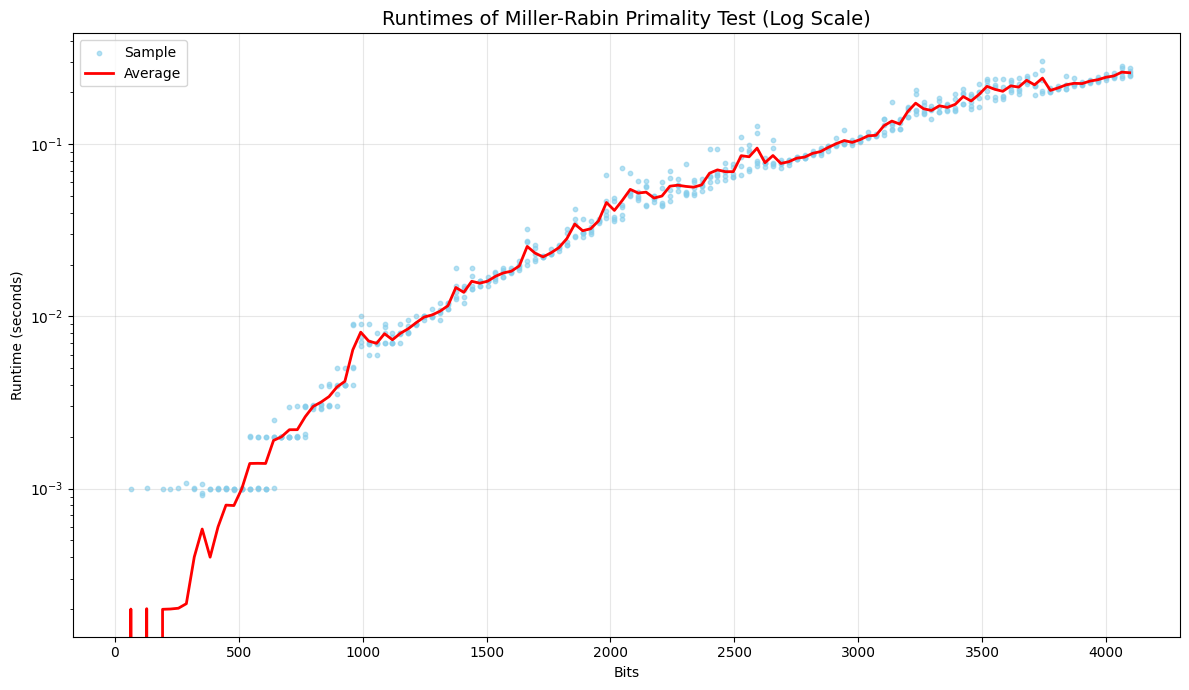

In [5]:
import time
import random
import matplotlib.pyplot as plt


def generate_random_odd_number(bits):
    return random.getrandbits(bits) | (1 << (bits - 1)) | 1


def experiment_mr_detailed(max_bits=4096, step=64, k=10, trials=8):
    bit_sizes = list(range(step, max_bits + 1, step))

    all_samples_x = []
    all_samples_y = []
    avg_times = []

    print("Bits | Avg Time (s)")
    print("-" * 30)

    for bits in bit_sizes:
        times = []

        for _ in range(trials):
            n = generate_random_odd_number(bits)

            start = time.time()
            miller_rabin_wrapper(n, k)
            end = time.time()

            t = end - start
            times.append(t)

            # store sample points
            all_samples_x.append(bits)
            all_samples_y.append(t)

        avg_time = sum(times) / trials
        avg_times.append(avg_time)

        print(f"{bits:4d} | {avg_time:.6f}")

    # ---- Plot ----
    plt.figure(figsize=(12, 7))

    # Scatter samples (blue dots)
    plt.scatter(all_samples_x, all_samples_y,
                color='skyblue', s=10, alpha=0.6, label='Sample')

    # Average line (red)
    plt.plot(bit_sizes, avg_times,
             color='red', linewidth=2, label='Average')

    plt.title("Runtimes of Miller-Rabin Primality Test (Log Scale)", fontsize=14)
    plt.xlabel("Bits")
    plt.ylabel("Runtime (seconds)")

    plt.yscale('log')

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("mr_runtime_detailed.png", dpi=300)
    plt.show()


# Run
experiment_mr_detailed(max_bits=4096, step=32, k=10, trials=5)

In [6]:
import math


def aks(n):
    if is_power(n):
        return False

    r = find_r(n)

    if r is None:
        return True

    for a in range(2, int(math.sqrt(r)) + 1):
        if math.gcd(a, n) != 1:
            return False

    return True


def is_power(n):
    if n <= 1:
        return False

    max_exponent = int(math.log2(n))

    for b in range(2, int(math.sqrt(n)) + 1):
        i = 2
        while pow(b, i) <= n:
            if pow(b, i) == n:
                return True
            i += 1
        if i > max_exponent:
            break

    return False


def find_r(n):
    max_r = int(math.log2(n) ** 2)
    primes = sieve_of_eratosthenes(max_r)

    for r in primes:
        if r > n:
            return None
        if pow(n, n, r) != n % r:
            return r

    return None


def sieve_of_eratosthenes(n):
    primes = [True] * (n + 1)
    primes[0] = primes[1] = False

    p = 2

    while p * p <= n:
        if primes[p]:
            for i in range(p * p, n + 1, p):
                primes[i] = False
        p += 1

    return [p for p in range(n + 1) if primes[p]]

Bits | MR Avg | AKS Avg
-----------------------------------
   2 | 0.000000 | 0.000000
   4 | 0.000200 | 0.000000
   6 | 0.000000 | 0.000000
   8 | 0.000000 | 0.000000
  10 | 0.000000 | 0.000000
  12 | 0.000000 | 0.000000
  14 | 0.000000 | 0.000000
  16 | 0.000000 | 0.000000
  18 | 0.000000 | 0.000000
  20 | 0.000000 | 0.000000
  22 | 0.000000 | 0.000000
  24 | 0.000000 | 0.000000
  26 | 0.000000 | 0.000337
  28 | 0.000000 | 0.000000
  30 | 0.000000 | 0.000000
  32 | 0.000201 | 0.000000
  34 | 0.000000 | 0.000000
  36 | 0.000000 | 0.000200
  38 | 0.000000 | 0.000200
  40 | 0.000000 | 0.000200
  42 | 0.000000 | 0.000000
  44 | 0.000000 | 0.000200
  46 | 0.000000 | 0.000203
  48 | 0.000000 | 0.000198
  50 | 0.000000 | 0.000199
  52 | 0.000000 | 0.000400
  54 | 0.000000 | 0.000200
  56 | 0.000200 | 0.000000
  58 | 0.000000 | 0.000400
  60 | 0.000000 | 0.000201
  62 | 0.000000 | 0.000399
  64 | 0.000000 | 0.000200
  66 | 0.000000 | 0.000400
  68 | 0.000200 | 0.000200
  70 | 0.000000 | 0.00

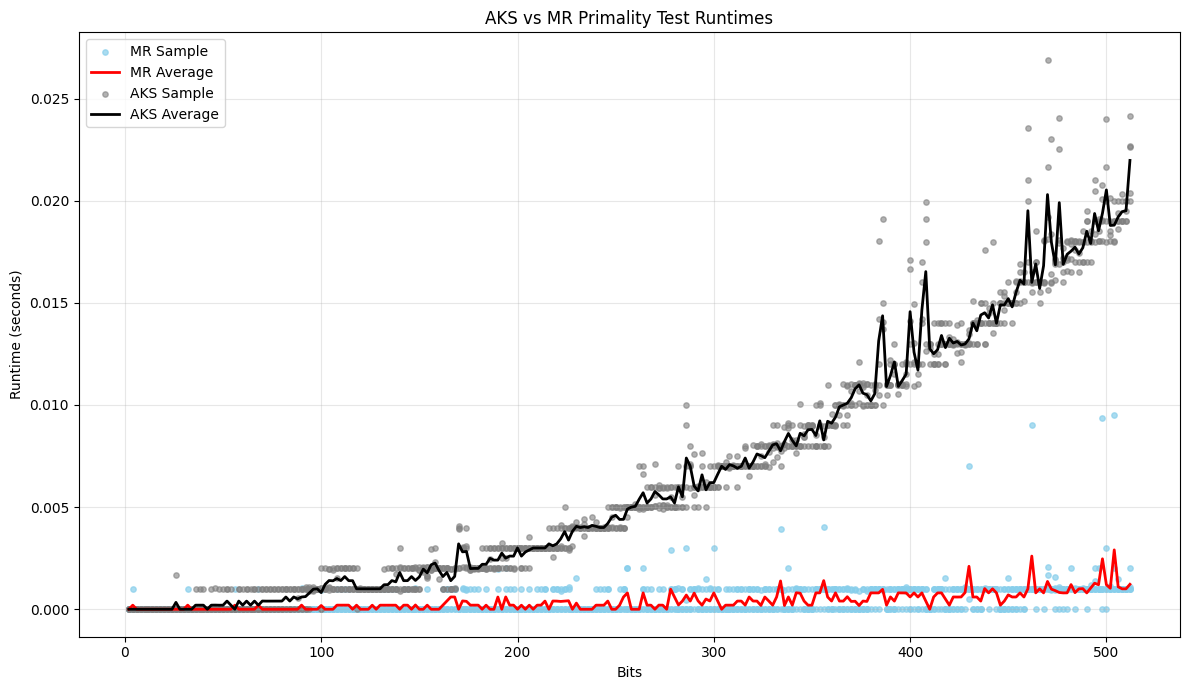

In [7]:
import time
import random
import matplotlib.pyplot as plt


def generate_random_odd_number(bits):
    return random.getrandbits(bits) | (1 << (bits - 1)) | 1


def experiment_mr_vs_aks_detailed(max_bits=1024, step=2, k=10, trials=5):
    bit_sizes = list(range(2, max_bits + 1, step))

    # Store samples
    mr_x, mr_y = [], []
    aks_x, aks_y = [], []

    mr_avg = []
    aks_avg = []

    print("Bits | MR Avg | AKS Avg")
    print("-" * 35)

    for bits in bit_sizes:
        mr_times = []
        aks_times = []

        for _ in range(trials):
            n = generate_random_odd_number(bits)

            # ---- MR ----
            start = time.time()
            miller_rabin_wrapper(n, k)
            t_mr = time.time() - start
            mr_times.append(t_mr)

            mr_x.append(bits)
            mr_y.append(t_mr)

            # ---- AKS ----
            start = time.time()
            aks(n)
            t_aks = time.time() - start
            aks_times.append(t_aks)

            aks_x.append(bits)
            aks_y.append(t_aks)

        # averages
        mr_avg_val = sum(mr_times) / trials
        aks_avg_val = sum(aks_times) / trials

        mr_avg.append(mr_avg_val)
        aks_avg.append(aks_avg_val)

        print(f"{bits:4d} | {mr_avg_val:.6f} | {aks_avg_val:.6f}")

    # -------- Plot --------
    plt.figure(figsize=(12, 7))

    # MR samples
    plt.scatter(mr_x, mr_y, s=15, alpha=0.7,color="skyblue", label="MR Sample")

    # MR average
    plt.plot(bit_sizes, mr_avg, color="red", linewidth=2, label="MR Average")

    # AKS samples
    plt.scatter(aks_x, aks_y, s=15, alpha=0.6, color="gray", label="AKS Sample")

    # AKS average
    plt.plot(bit_sizes, aks_avg, color="black", linewidth=2, label="AKS Average")

    plt.xlabel("Bits")
    plt.ylabel("Runtime (seconds)")
    plt.title("AKS vs MR Primality Test Runtimes")

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("aks_vs_mr_detailed.png", dpi=300)
    plt.show()


# Run
experiment_mr_vs_aks_detailed(max_bits=512, step=2, k=10, trials=5)

Bits | MR Avg | AKS Avg
-----------------------------------
   2 | 0.000000 | 0.000000
  10 | 0.000000 | 0.000000
  18 | 0.000000 | 0.000000
  26 | 0.000000 | 0.000104
  34 | 0.000000 | 0.000102
  42 | 0.000000 | 0.000203
  50 | 0.000000 | 0.000000
  58 | 0.000000 | 0.000289
  66 | 0.000000 | 0.000525
  74 | 0.000000 | 0.000400
  82 | 0.000200 | 0.000400
  90 | 0.000000 | 0.000600
  98 | 0.000000 | 0.000800
 106 | 0.000201 | 0.000801
 114 | 0.000000 | 0.001001
 122 | 0.000000 | 0.000998
 130 | 0.000200 | 0.001310
 138 | 0.000200 | 0.001200
 146 | 0.000201 | 0.001399
 154 | 0.000198 | 0.001401
 162 | 0.000401 | 0.001600
 170 | 0.000000 | 0.002000
 178 | 0.000000 | 0.002200
 186 | 0.000398 | 0.002302
 194 | 0.000200 | 0.002605
 202 | 0.000000 | 0.003105
 210 | 0.000000 | 0.003000
 218 | 0.000200 | 0.003200
 226 | 0.000201 | 0.003592
 234 | 0.000000 | 0.004218
 242 | 0.000400 | 0.004184
 250 | 0.000401 | 0.004268
 258 | 0.000601 | 0.006027
 266 | 0.000327 | 0.005257
 274 | 0.000400 | 0.00

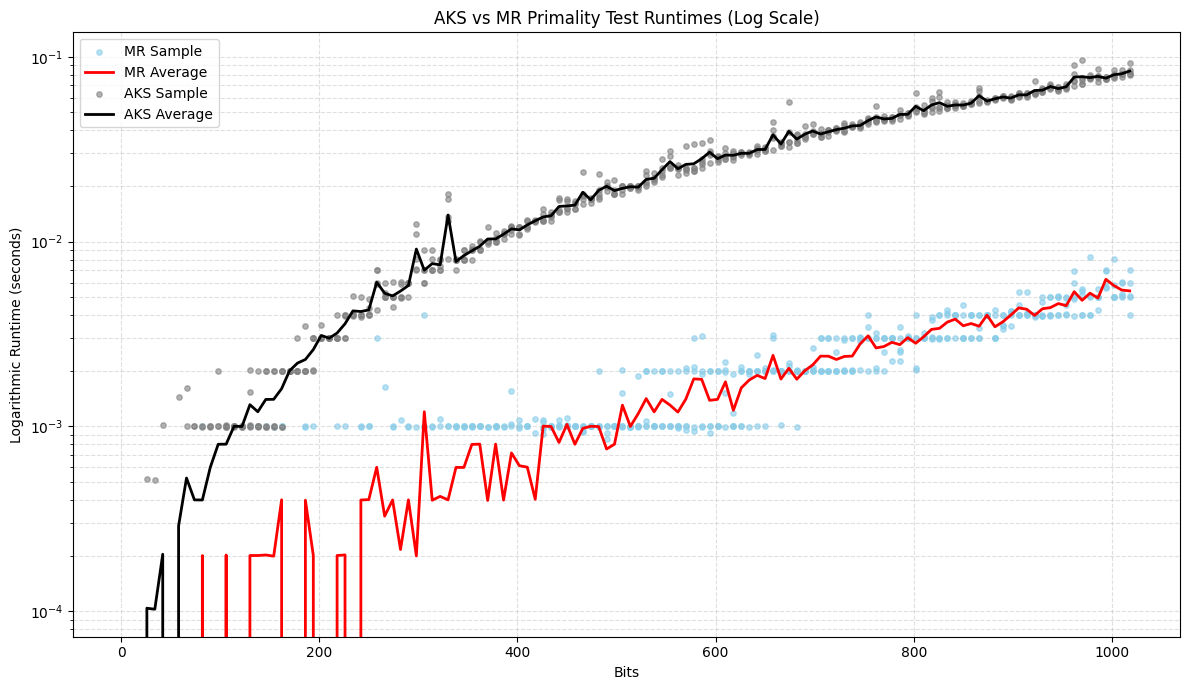

In [8]:
import time
import random
import matplotlib.pyplot as plt


def generate_random_odd_number(bits):
    return random.getrandbits(bits) | (1 << (bits - 1)) | 1


def experiment_mr_vs_aks_detailed(max_bits=512, step=2, k=10, trials=5):
    bit_sizes = list(range(2, max_bits + 1, step))

    mr_x, mr_y = [], []
    aks_x, aks_y = [], []

    mr_avg = []
    aks_avg = []

    print("Bits | MR Avg | AKS Avg")
    print("-" * 35)

    for bits in bit_sizes:
        mr_times = []
        aks_times = []

        for _ in range(trials):
            n = generate_random_odd_number(bits)

            # ---- MR ----
            start = time.time()
            miller_rabin_wrapper(n, k)
            t_mr = time.time() - start  
            mr_times.append(t_mr)

            mr_x.append(bits)
            mr_y.append(t_mr)

            # ---- AKS ----
            start = time.time()
            aks(n)
            t_aks = time.time() - start 
            aks_times.append(t_aks)

            aks_x.append(bits)
            aks_y.append(t_aks)

        mr_avg_val = sum(mr_times) / trials
        aks_avg_val = sum(aks_times) / trials

        mr_avg.append(mr_avg_val)
        aks_avg.append(aks_avg_val)

        print(f"{bits:4d} | {mr_avg_val:.6f} | {aks_avg_val:.6f}")

    # -------- Plot --------
    plt.figure(figsize=(12, 7))

    # MR
    plt.scatter(mr_x, mr_y, s=15, alpha=0.6, color="skyblue", label="MR Sample")
    plt.plot(bit_sizes, mr_avg, color="red", linewidth=2, label="MR Average")

    # AKS
    plt.scatter(aks_x, aks_y, s=15, alpha=0.6, color="gray", label="AKS Sample")
    plt.plot(bit_sizes, aks_avg, color="black", linewidth=2, label="AKS Average")

    # 🔥 LOG SCALE
    plt.yscale('log')

    plt.xlabel("Bits")
    plt.ylabel("Logarithmic Runtime (seconds)")
    plt.title("AKS vs MR Primality Test Runtimes (Log Scale)")

    plt.legend()

    # Better grid for log scale
    plt.grid(True, which="both", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig("aks_vs_mr_log.png", dpi=300)
    plt.show()


# Run
experiment_mr_vs_aks_detailed(max_bits=1024, step=8, k=10, trials=5)


Number of Witnesses (k) | Carmichael Conflicts | Random Conflicts
---------------------------------------------------------------------------
k = 1                   | 325                  | 170             
k = 2                   | 235                  | 154             
k = 3                   | 231                  | 194             
k = 5                   | 252                  | 172             
k = 10                  | 246                  | 178             
k = 15                  | 259                  | 184             
k = 20                  | 242                  | 183             


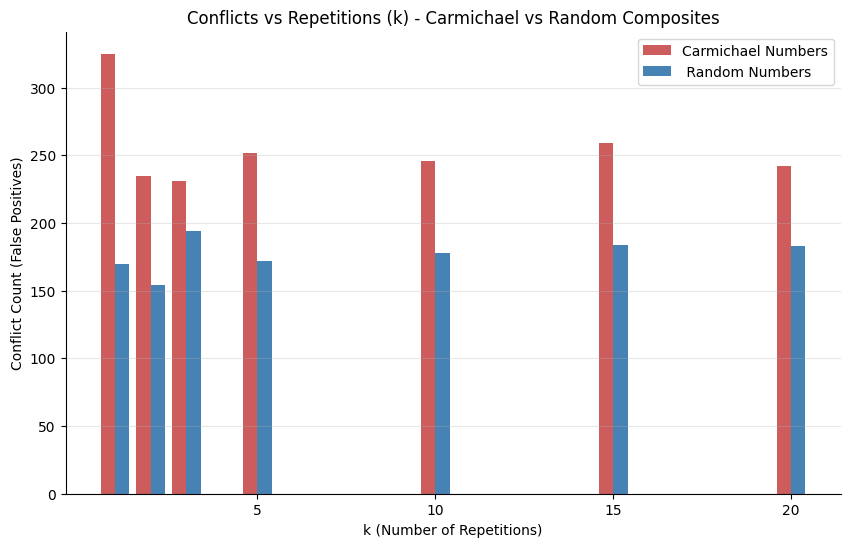

({1: 325, 2: 235, 3: 231, 5: 252, 10: 246, 15: 259, 20: 242},
 {1: 170, 2: 154, 3: 194, 5: 172, 10: 178, 15: 184, 20: 183})

In [9]:
#Error probability comparison for Miller-Rabin with different rounds
def error_probability(num_tests=1000, witnesses_range=[1, 2, 3, 5, 10, 15, 20]):
    """
    Demonstrate how the number of witnesses affects the error probability
    by counting conflicts (false positives on composite numbers).
    """
    import matplotlib.pyplot as plt
    import random
    
    results_carmichael = {}
    results_random = {}
    
    print("\nNumber of Witnesses (k) | Carmichael Conflicts | Random Conflicts")
    print("-" * 75)

    # Some known Carmichael numbers (very tough composites) that fool MR on many bases
    tough_composites = [29341, 41041, 46657, 52633, 62745, 63973, 75361, 105527]
    
    # Generate 1000 random composites for comparison
    random_composites = []
    while len(random_composites) < 1000:
        num = random.randint(10000, 100000)
        # # Ensure it's odd and definitively not prime
        # if num % 2 != 0 and not miller_rabin_wrapper(num, k=20):
        random_composites.append(num)

    for witnesses in witnesses_range:
        carmichael_conflicts = 0
        random_conflicts = 0

        # Test Carmichael numbers
        for _ in range(num_tests):
            n = random.choice(tough_composites)
            if miller_rabin_wrapper(n, k=witnesses):
                carmichael_conflicts += 1
                
        # Test 1000 Random Generated Numbers
        for _ in range(num_tests):
            
            n = random.choice(random_composites)
            if miller_rabin_wrapper(n, k=witnesses):
                random_conflicts += 1

        results_carmichael[witnesses] = carmichael_conflicts
        results_random[witnesses] = random_conflicts
        
        # Print side-by-side comparison
        print(f"k = {witnesses:<19} | {carmichael_conflicts:<20} | {random_conflicts:<16}")
        
    plt.figure(figsize=(10, 6))
    
    # Create Side-by-Side Bar Graphs
    width = 0.4
    x_positions = list(results_carmichael.keys())
    
    plt.bar([x - width/2 for x in x_positions], list(results_carmichael.values()), 
            color='indianred', width=width, label='Carmichael Numbers')
    plt.bar([x + width/2 for x in x_positions], list(results_random.values()), 
            color='steelblue', width=width, label=' Random Numbers')
    
    plt.xlabel('k (Number of Repetitions)')
    plt.ylabel('Conflict Count (False Positives)')
    plt.title('Conflicts vs Repetitions (k) - Carmichael vs Random Composites')
    
    # Match x-ticks logically
    plt.xticks([5, 10, 15, 20])
    plt.legend()
        
    # Styling to match the simple, clean look
    plt.grid(axis='y', linestyle='-', alpha=0.3)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.show()

    return results_carmichael, results_random

# Tweak num_tests to control the maximum height of the bar at k=1
error_probability(num_tests=2000, witnesses_range=[1, 2, 3, 5, 10, 15, 20])

Benchmarking 100-bit inputs...
Benchmarking 200-bit inputs...
Benchmarking 300-bit inputs...
Benchmarking 400-bit inputs...
Benchmarking 500-bit inputs...
Benchmarking 600-bit inputs...
Benchmarking 700-bit inputs...
Benchmarking 800-bit inputs...
Benchmarking 900-bit inputs...
Benchmarking 1000-bit inputs...
    x |    100 |    200 |    300 |    400 |    500 |    600 |    700 |    800 |    900 |   1000
-----------------------------------------------------------------------------------------------
    0 |   36.0 |   27.0 |   26.0 |   24.0 |   21.0 |   20.0 |   20.5 |   19.5 |   20.5 |   26.5
   10 |   28.0 |   21.0 |   15.0 |   15.5 |    8.0 |    9.5 |    9.0 |   13.5 |   14.0 |   11.5
   20 |   17.5 |   17.5 |   11.5 |   12.5 |    8.0 |    7.5 |    7.0 |   10.0 |    9.5 |    8.0
   30 |   14.5 |    8.5 |    7.0 |    8.5 |    6.5 |    6.5 |    6.0 |    6.5 |    6.0 |    5.5
   40 |   10.0 |    5.0 |    2.0 |    3.5 |    2.5 |    2.0 |    0.5 |    3.5 |    4.0 |    0.5
   50 |    6.0 | 

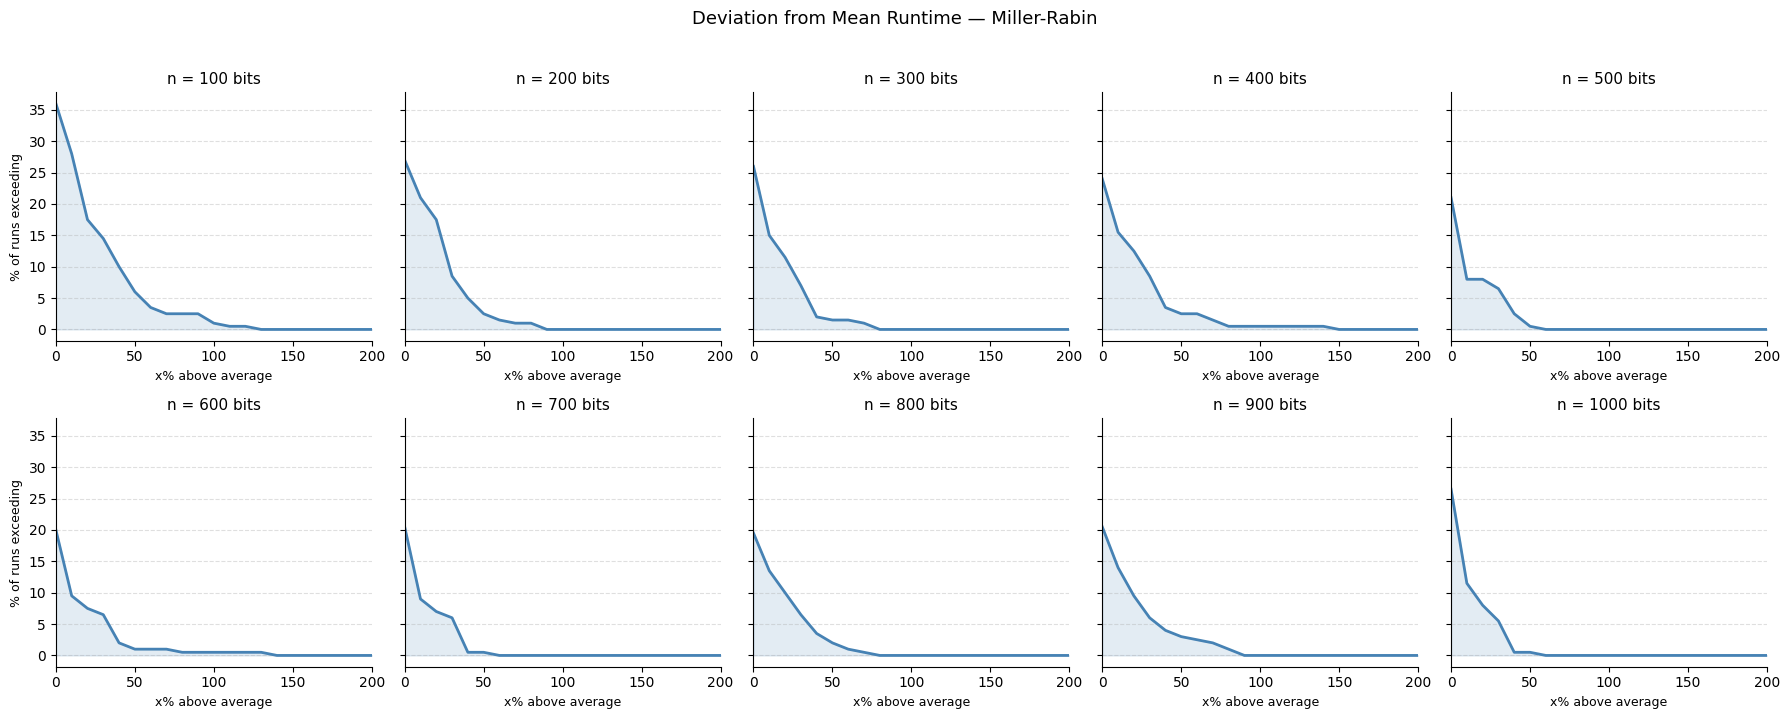

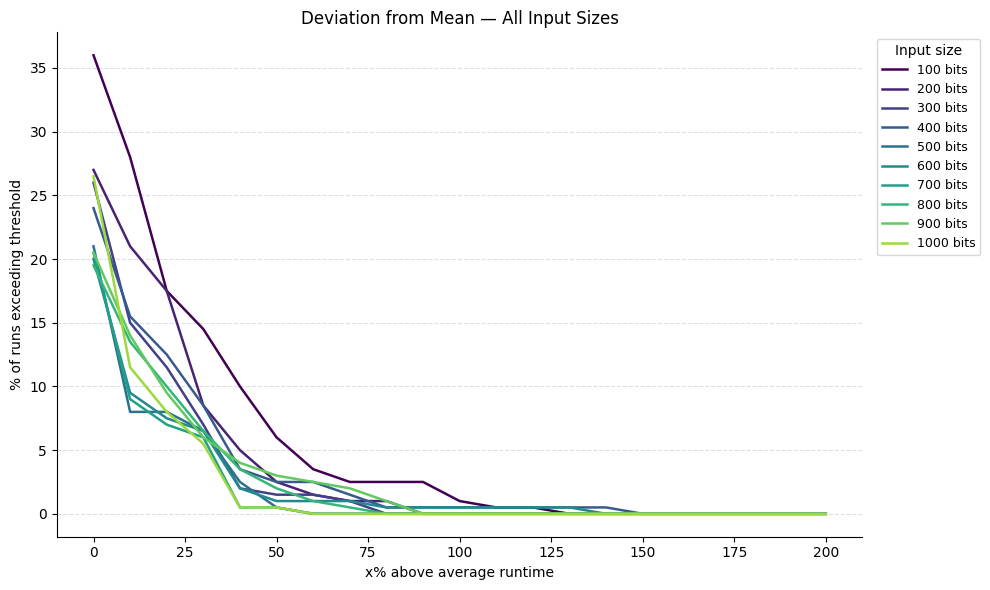

In [10]:
import time
import random
import csv
import timeit
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

def benchmark_mr(n_bits, num_runs=2000, k=5):
    times = []
    repeat = 10

    for _ in range(num_runs):
        elapsed = timeit.timeit(
            lambda: miller_rabin_wrapper(
                random.getrandbits(n_bits) | (1 << (n_bits - 1)) | 1, k=k
            ),
            number=repeat
        )
        times.append(elapsed / repeat + 1e-9)

    return times

# --- Parameters ---
input_sizes = [100, 200, 300, 400, 500, 600, 700,800,900,1000]
x_thresholds = list(range(0, 210, 10))
num_runs = 200

# --- Collect runtimes ---
all_times = {}
for n in input_sizes:
    print(f"Benchmarking {n}-bit inputs...")
    all_times[n] = benchmark_mr(n, num_runs=num_runs)

# --- Build the table ---
table = defaultdict(dict)
means = {}

for n in input_sizes:
    times = np.array(all_times[n])
    means[n] = np.mean(times)
    for x in x_thresholds:
        threshold = means[n]  * (1 + x / 100)
        pct = np.sum(times >= threshold) / len(times) * 100
        table[x][n] = round(pct, 3)



with open('mr_runtimes.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['n_bits', 'run_index', 'runtime_seconds'])
    for n in input_sizes:
        for i, t in enumerate(all_times[n]):
            writer.writerow([n, i, t])
# --- Print table ---
header = f"{'x':>5} | " + " | ".join(f"{n:>6}" for n in input_sizes)
print(header)
print("-" * len(header))
for x in x_thresholds:
    row = f"{x:>5} | " + " | ".join(f"{table[x][n]:>6.1f}" for n in input_sizes)
    print(row)

# --- Individual deviation graphs (one per input size) ---
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
axes = axes.flatten()

for idx, n in enumerate(input_sizes):
    ax = axes[idx]
    y_vals = [table[x][n] for x in x_thresholds]

    ax.plot(x_thresholds, y_vals, color='steelblue', linewidth=2)
    ax.fill_between(x_thresholds, y_vals, alpha=0.15, color='steelblue')

    ax.set_title(f'n = {n} bits', fontsize=11)
    ax.set_xlabel('x% above average', fontsize=9)
    ax.set_ylabel('% of runs exceeding' if idx % 5 == 0 else '', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 200)

plt.suptitle('Deviation from Mean Runtime — Miller-Rabin', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('deviation_by_input_size.png', dpi=150, bbox_inches='tight')
plt.show()

# --- All input sizes overlaid on one graph ---
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 0.85, len(input_sizes)))
for idx, n in enumerate(input_sizes):
    y_vals = [table[x][n] for x in x_thresholds]
    plt.plot(x_thresholds, y_vals, label=f'{n} bits', color=colors[idx], linewidth=1.8)

plt.xlabel('x% above average runtime')
plt.ylabel('% of runs exceeding threshold')
plt.title('Deviation from Mean — All Input Sizes')
plt.legend(title='Input size', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('deviation_overlay.png', dpi=150, bbox_inches='tight')
plt.show()